In [21]:
import pandas as pd
import folium

test1 = "25-10-05_20-57-14.csv"
test2 = "25-10-06_12-08-21.csv"
test3 = "25-10-06_12-35-01.csv"

df = pd.read_csv(test1, header=2)
df['time'] = pd.to_datetime(df['time'], format='%y-%m-%d %H:%M:%S')
df.set_index('time', inplace=True)

# def ddmm_to_decimal(coord):
#     s = str(coord).strip()
#     sign = -1 if s.startswith('-') else 1
#     s = s.lstrip('+-')
#     whole, frac = (s.split('.') + ['0'])[:2]
#     deg_digits = len(whole) - 2
#     deg = int(whole[:deg_digits])
#     minutes = float(whole[deg_digits:] + '.' + frac)
#     return sign * (deg + minutes / 60.0)

# df['lat_decimal'] = df['lat'].apply(ddmm_to_decimal)
# df['lon_decimal'] = df['lon'].apply(ddmm_to_decimal)

# # DO NOT negate longitude again — your CSV already includes the sign

# print(df[['lat', 'lon', 'lat_decimal', 'lon_decimal']].head())

# Plot
m = folium.Map(location=[df.iloc[0]['lat'], df.iloc[0]['lon']], zoom_start=16)
coords = df[['lat', 'lon']].values.tolist()
folium.PolyLine(coords, color='blue', weight=2.5, opacity=1).add_to(m)
m.save('20251006_capeCod_test1.html')

In [7]:
# --- Calculate sample rate (Hz) ---
time_diffs = df.index.to_series().diff().dropna().dt.total_seconds()
avg_sample_period = time_diffs.mean()
sample_rate_hz = 1 / avg_sample_period if avg_sample_period != 0 else float('nan')

print(f"Average sample period: {avg_sample_period:.6f} s")
print(f"Sampling frequency: {sample_rate_hz:.3f} Hz")

Average sample period: 11.150855 s
Sampling frequency: 0.090 Hz


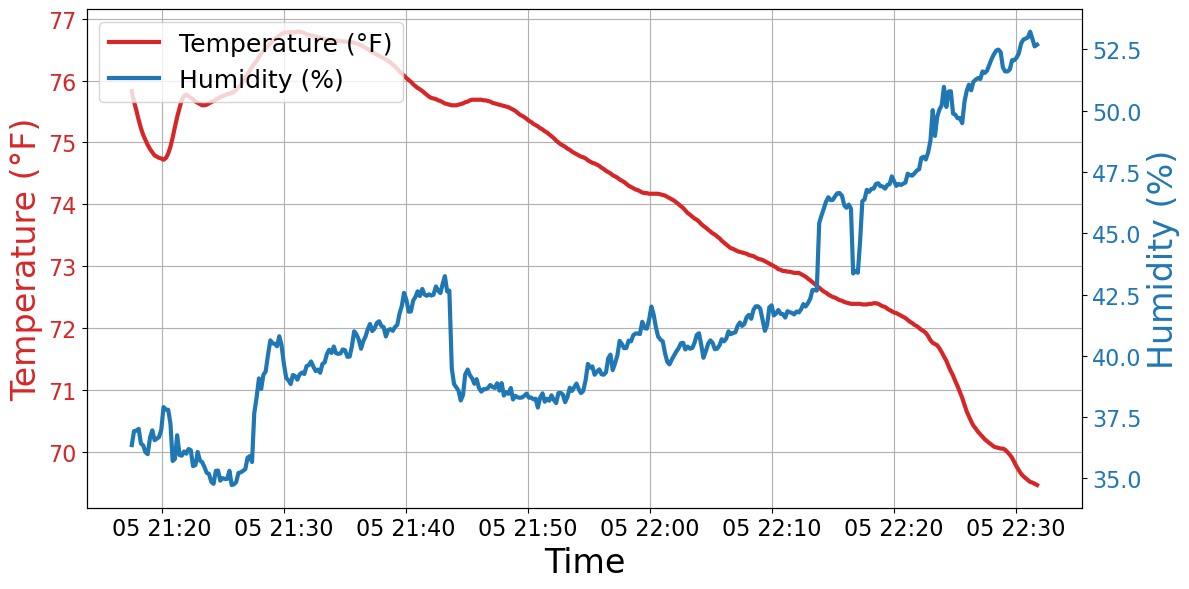

In [29]:
import matplotlib.pyplot as plt

df = pd.read_csv(test1, header=2)
df['time'] = pd.to_datetime(df['time'], format='%y-%m-%d %H:%M:%S')
df.set_index('time', inplace=True)

df = df.iloc[90:490]
# df_slice = df.loc['2025-10-06 12:10:00':'2025-10-06 12:15:00']

# --- Plot with dual y-axes ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Temperature (left y-axis)
lns1 = ax1.plot(df.index, df['tempF'], color='tab:red', lw=3, label='Temperature (°F)')
ax1.set_xlabel('Time', fontsize=24)
ax1.set_ylabel('Temperature (°F)', color='tab:red', fontsize=24)
ax1.tick_params(axis='y', labelcolor='tab:red', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)
ax1.grid()

# Humidity (right y-axis)
ax2 = ax1.twinx()
lns2 = ax2.plot(df.index, df['humidity'], color='tab:blue', lw=3, label='Humidity (%)')
ax2.set_ylabel('Humidity (%)', color='tab:blue', fontsize=24)
ax2.tick_params(axis='y', labelcolor='tab:blue', labelsize=16)

# --- Combine legends ---
lns = lns1 + lns2
labels = [l.get_label() for l in lns]
ax1.legend(lns, labels, fontsize=18, loc='upper left')

# plt.title('Temperature and Humidity vs Time', fontsize=24)
plt.tight_layout()
plt.show()

In [33]:
import folium 

# Create a Folium map centered at the first location
m = folium.Map(location=[df.iloc[0]['lat_decimal'], df.iloc[0]['lon_decimal']], zoom_start=16)

# Prepare the coordinates for the polyline
coordinates = df[['lat_decimal', 'lon_decimal']].values.tolist()

# Add a line connecting the points
folium.PolyLine(coordinates, color='blue', weight=2.5, opacity=1).add_to(m)

# Save map to an HTML file
m.save('20251005_capeCod.html')


C:\Users\sscop\AppData\Local\Temp\ipykernel_23020\2520031456.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


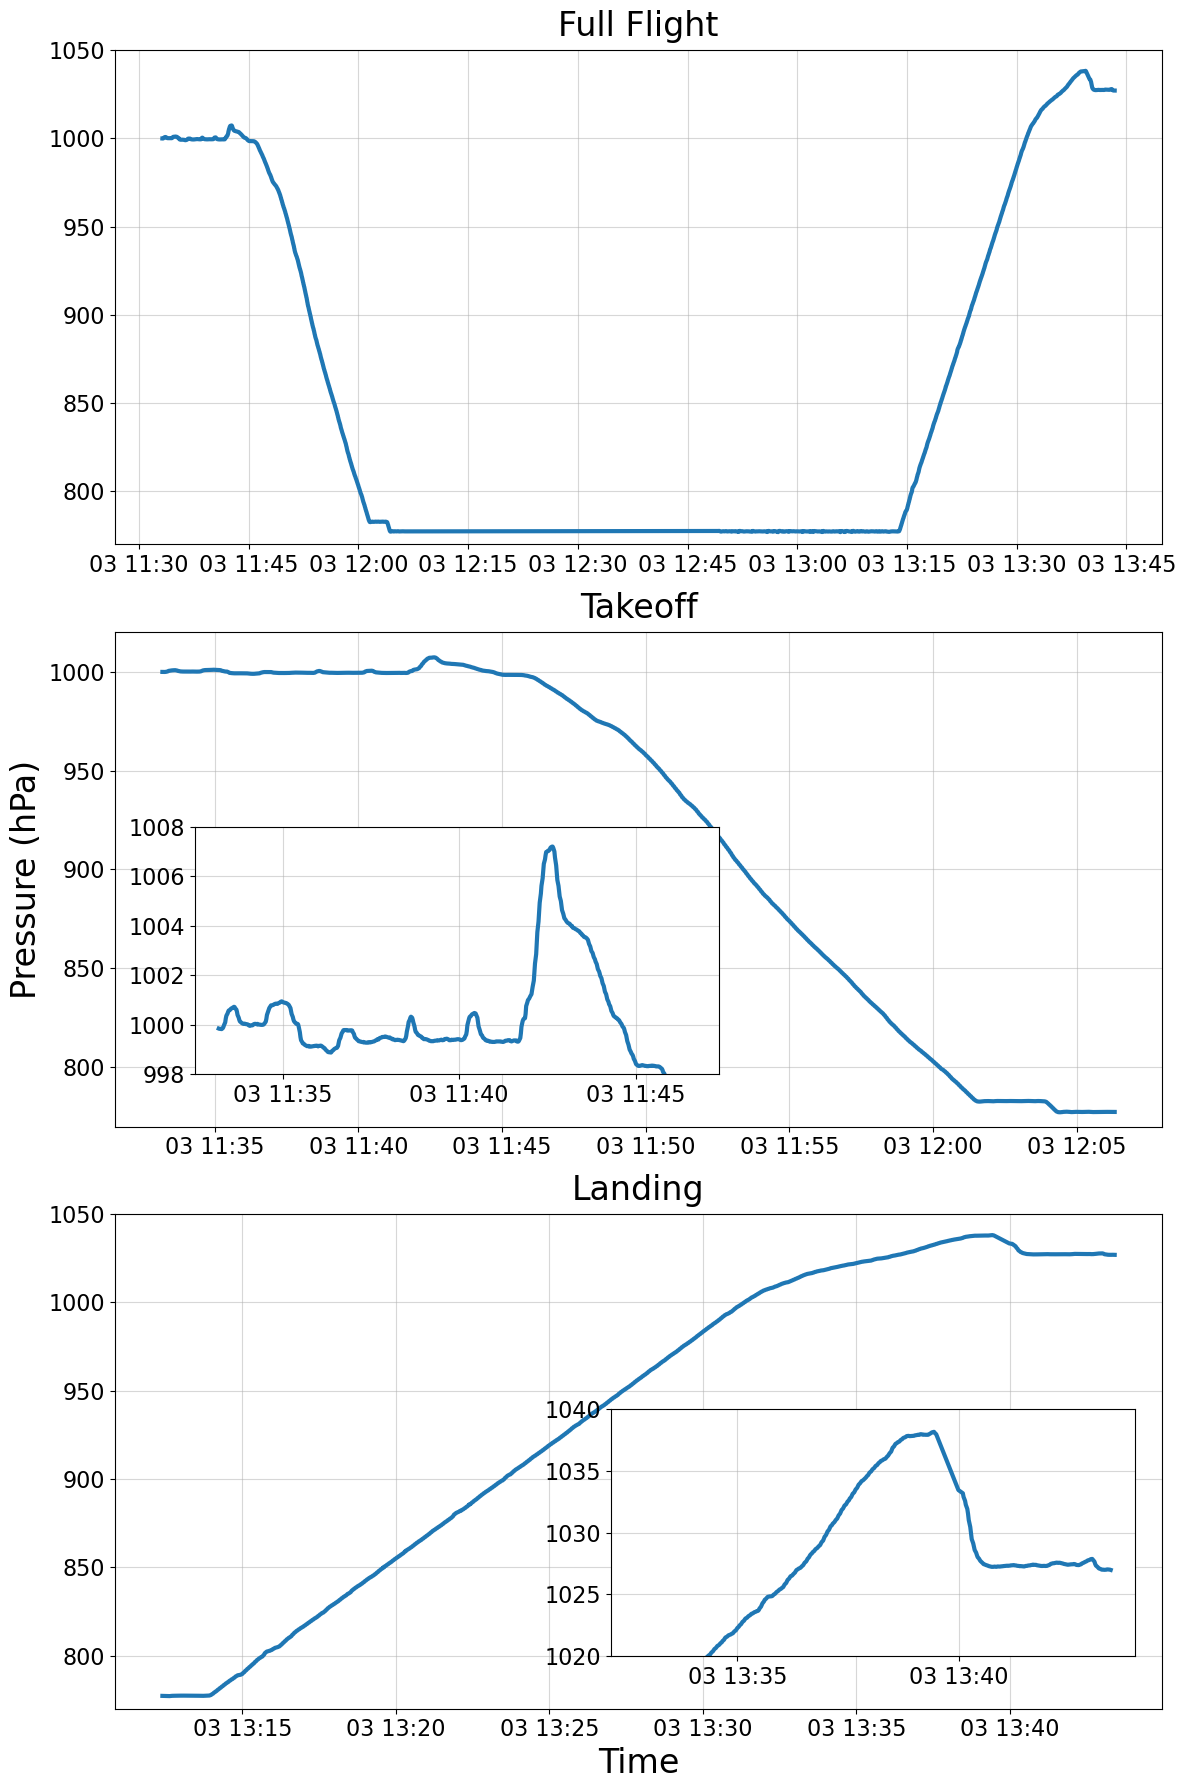

In [61]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=False)

# === 1) Full Flight ===
ax = axes[0]
ax.plot(df.index, df["pressurehPa"], lw=3)
ax.set_title("Full Flight", fontsize=24, pad=10)
ax.set_ylim(770, 1050)
ax.grid(alpha=0.5)
ax.tick_params(axis="both", labelsize=16)

# === 2) Takeoff ===
ax = axes[1]
ax.plot(takeoff_all.index, takeoff_all["pressurehPa"], lw=3)
ax.set_title("Takeoff", fontsize=24, pad=10)
ax.set_ylabel("Pressure (hPa)", fontsize=24)
ax.set_ylim(770, 1020)
ax.grid(alpha=0.5)
ax.tick_params(axis="both", labelsize=16)

# --- Inset for takeoff ---
axins = inset_axes(
    ax,
    width="50%",
    height="50%",
    loc="lower left",
    borderpad=2,
    bbox_to_anchor=(0.05, 0.05, 1, 1),
    bbox_transform=ax.transAxes,
)
axins.plot(takeoff.index, takeoff["pressurehPa"], color="tab:blue", lw=3)
axins.set_ylim(998, 1008)
axins.grid(alpha=0.5)
axins.tick_params(axis="both", labelsize=16)

# === 3) Landing ===
ax = axes[2]
ax.plot(landing_all.index, landing_all["pressurehPa"], lw=3)
ax.set_title("Landing", fontsize=24, pad=10)
ax.set_xlabel("Time", fontsize=24)
ax.set_ylim(770, 1050)
ax.grid(alpha=0.5)
ax.tick_params(axis="both", labelsize=16)

# --- Inset for landing ---
axins = inset_axes(
    ax,
    width="50%",
    height="50%",
    loc="lower right",
    borderpad=2,
    bbox_to_anchor=(0, 0.05, 1, 1),
    bbox_transform=ax.transAxes,
)
axins.plot(landing.index, landing["pressurehPa"], color="tab:blue", lw=3)
axins.set_ylim(1020, 1040)
axins.grid(alpha=0.5)
axins.tick_params(axis="both", labelsize=16)

plt.tight_layout()
plt.show()
